# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [7]:
import pandas as pd

# Load the dataset
df_banknote = pd.read_csv('data_banknote_authentication.csv')

# Quick exploration
print(df_banknote.head())
print(df_banknote.info())
print(df_banknote.describe())

# Check class balance
print(df_banknote['Class'].value_counts())

   Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  Image_Entropy  Class
0           3.62160            8.6661           -2.8073       -0.44699      0
1           4.54590            8.1674           -2.4586       -1.46210      0
2           3.86600           -2.6383            1.9242        0.10645      0
3           3.45660            9.5228           -4.0112       -3.59440      0
4           0.32924           -4.4552            4.5718       -0.98880      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None
       Variance_Wavelet  Skewness_Wavelet

In [8]:
# Features and target
X_banknote = df_banknote.drop('Class', axis=1)
y_banknote = df_banknote['Class']

# Train-test split (90% train, 10% test)
from sklearn.model_selection import train_test_split

X_train_bank, X_test_bank, y_train_bank, y_test_bank = train_test_split(
    X_banknote, y_banknote, test_size=0.1, random_state=42
)

# Check shapes
print("X_train shape:", X_train_bank.shape)
print("X_test shape:", X_test_bank.shape)

X_train shape: (1234, 4)
X_test shape: (138, 4)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create pipeline
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),   # optional for trees
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Hyperparameter grid
dt_param_grid = {
    'dt__max_depth': [None, 2, 4, 6, 8, 10],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
dt_grid.fit(X_train_bank, y_train_bank)

# Best params & CV score
print("Decision Tree Best Params:", dt_grid.best_params_)
print("Decision Tree Best CV Accuracy:", dt_grid.best_score_)

Decision Tree Best Params: {'dt__max_depth': None, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Decision Tree Best CV Accuracy: 0.9829860768243309


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),   # optional
    ('rf', RandomForestClassifier(random_state=42))
])

# Hyperparameter grid
rf_param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 4, 6, 8],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
rf_grid.fit(X_train_bank, y_train_bank)

# Best params & CV score
print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest Best CV Accuracy:", rf_grid.best_score_)

Random Forest Best Params: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Random Forest Best CV Accuracy: 0.9935156841446957


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Decision Tree Evaluation
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_bank)

print("Decision Tree Classification Report:\n", classification_report(y_test_bank, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test_bank, y_pred_dt))

# Random Forest Evaluation
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_bank)

print("Random Forest Classification Report:\n", classification_report(y_test_bank, y_pred_rf))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test_bank, y_pred_rf))

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        77
           1       0.98      0.98      0.98        61

    accuracy                           0.99       138
   macro avg       0.99      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138

Decision Tree Confusion Matrix:
 [[76  1]
 [ 1 60]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        77
           1       1.00      0.98      0.99        61

    accuracy                           0.99       138
   macro avg       0.99      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138

Random Forest Confusion Matrix:
 [[77  0]
 [ 1 60]]


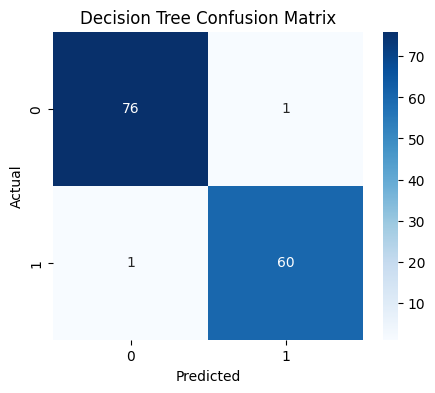

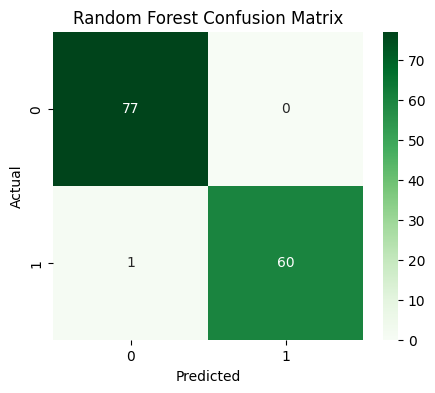

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Decision Tree Heatmap
cm_dt = confusion_matrix(y_test_bank, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Random Forest Heatmap
cm_rf = confusion_matrix(y_test_bank, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
#visual of confusion matrices